In [52]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns

import matplotlib.pyplot as plt

# Loading Data

In [53]:
df = pd.read_pickle("../../../data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [54]:
df_train.head(2)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."


In [55]:
# Split the business description embedding string into its components
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

In [56]:
# Fit the label encoder to the classes (industry names)
label_encoder =  LabelEncoder().fit(df_train.industry)

In [57]:
print(f"Train count {len(df_train.industry.unique())} Val count {len(df_val.industry.unique())}")

Train count 25 Val count 25


In [58]:
if all(val_label in df_val.industry.unique() for val_label in df_train.industry.unique()):
    print("All val labels are also in train set")
else:
    print("Val does NOT contain the same labels as the train set")

All val labels are also in train set


In [59]:
y_train = label_encoder.transform(df_train.industry)
y_val =  label_encoder.transform(df_val.industry)

# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

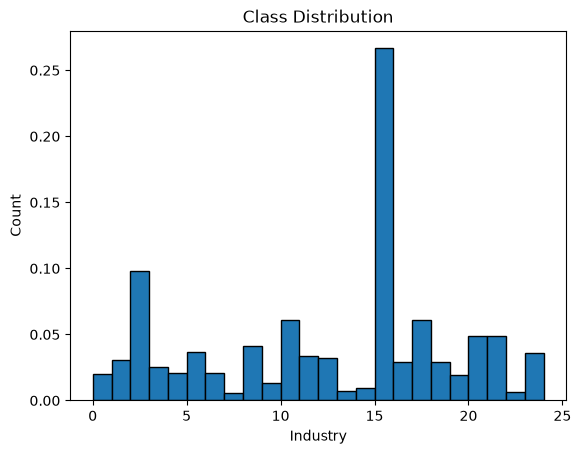

Counts per class:


industry
Materials                                         7604
Capital Goods                                     2805
Pharmaceuticals, Biotechnology & Life Sciences    1742
Financial Services                                1740
Technology Hardware & Equipment                   1390
Software & Services                               1384
Energy                                            1174
Consumer Durables & Apparel                       1037
Food, Beverage & Tobacco                           956
Health Care Equipment & Services                   911
Banks                                              874
Media & Entertainment                              827
Real Estate Management & Development               825
Commercial & Professional Services                 726
Consumer Discretionary Distribution & Retail       591
Consumer Services                                  591
Automobiles & Components                           572
Semiconductors & Semiconductor Equipment           545
T

In [ ]:
# Plot the class distribution or provide a table that shows how many times each class (industry) appears
# Describe your findings
values, bins, bars = plt.hist(y_train, bins=range(len(df_train.industry.unique())), edgecolor='black', density=True)
plt.title("Class Distribution")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.show()

print("Counts per class:")
df_train.industry.value_counts()

There are some industries like "materials" and "capital goods" that contain a lot more samples than others. Then there is a large middle section of industries with 500 to 1000  samples and at the end is a small numbe rof industries who have fewer than 500 samples.

Because a quarter of the samples is of the industry "materials", a naive classifier that only predicts that class can already reach an accuracy of ca. ~25%. 

To make sure that the classifier learns to predict the right class and not only that this is the majority class, we need to account for this.

This could be done through adjusting the loss function or using a classifier that can inversely weight the samples by the class's frequency.

A different approach would be to use a technique like SMOTE, or reducing the number of samples in the majority class to make it more equal. Although i think that we do want to use all the samples that we have.

Regarding if these numbers make sense. I am not 100% sure, but i think they look mostly sensible.

### PCA - Dimensionality reduction and visualization

(28535, 768)


(28535, 2)


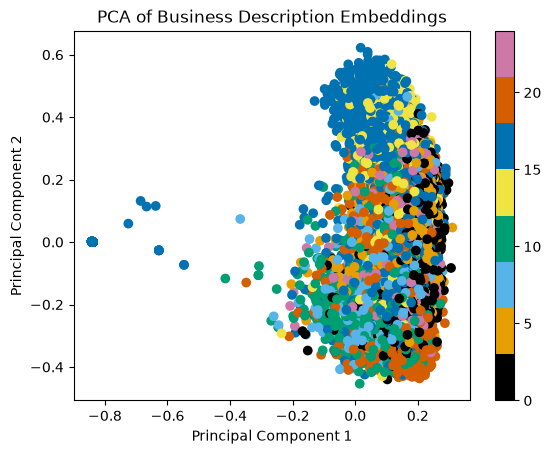

In [81]:
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see
print(X_train.shape)
pca = PCA(n_components=2).fit_transform(X_train)
print(pca.shape)
plt.scatter(pca[:, 0], pca[:, 1], c=y_train, cmap="okabe_ito")
plt.title("PCA of Business Description Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [ ]:
# your code

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of an industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- Designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

## Scoring

Your submission is scored with the function `confidence_score` below:

$$\text{score} = F_1^{\text{weighted}}(y, \hat{y}_{pred}) \cdot \left(1 - \text{Brier}\right), \qquad \text{Brier} = \frac{1}{n}\sum_{i=1}^{n} \left(\hat{y}_{confidence}[i] - \mathbb{1}[\hat{y}_{pred}[i] = y_i]\right)^2$$

- **Weighted F1** measures how good your predicted industries are (the confidence does not enter here).
- **Brier score** measures how good your confidence is: $\hat{y}_{confidence}[i]$ should be the probability that prediction $i$ is correct.
- The Brier term is smallest when your confidence is *calibrated*: among all predictions with confidence 0.8, about 80% should be correct.
- Always reporting confidence 1.0 does not pay off (every wrong prediction costs the maximum penalty), and neither does reporting very low confidence everywhere.

In [ ]:
from sklearn.metrics import f1_score


def confidence_score(y_true, y_pred, confidence):
    """
    Score for the confidence weighted prediction task.

    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    confidence : array-like
        Confidence for each prediction, in [0, 1]
        (= estimated probability that the prediction is correct)

    Returns:
    --------
    float
        weighted F1 * (1 - Brier score), between 0 and 1 (higher is better)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence, dtype=float)

    assert len(y_true) == len(y_pred) == len(confidence), "Inputs must have the same length"
    assert np.all((confidence >= 0) & (confidence <= 1)), "Confidence must be between 0 and 1"

    f1 = f1_score(y_true, y_pred, average="weighted")
    correct = (y_true == y_pred).astype(float)
    brier = np.mean((confidence - correct) ** 2)

    return f1 * (1 - brier)

In [ ]:
# Example: evaluate a model on the validation set
# (requires y_train and y_val from the label encoding task)

example_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

y_proba = example_model.predict_proba(X_val)
y_pred = example_model.classes_[np.argmax(y_proba, axis=1)]
confidence = np.max(y_proba, axis=1)  # probability of the predicted class

print("Score with model confidence:  {:.4f}".format(confidence_score(y_val, y_pred, confidence)))
print("Score with confidence = 1.0:  {:.4f}".format(confidence_score(y_val, y_pred, np.ones(len(y_pred)))))